In [69]:
# Imports
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection  import train_test_split
import ml_pokedex as mlpo
importlib.reload(mlpo)

<module 'ml_pokedex' from 'c:\\Users\\Dell\\Documents\\Códigos\\PoupaTempos\\ML-Pokedex\\ml_pokedex.py'>

In [ ]:
# Carregar dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [ ]:
df_clean, report_data = mlpo.quality_processor(df, df.columns, num_strategy='knn', cat_strategy='most_frequent', encoding='label', knn_neighbors=5)
report_data

,Coluna,Imputação,Encoder,Nulls (Antes),Nulls (Depois),Ref Média (Antes),Ref Média (Depois)
0,sepal length (cm),knn,N/A,0,0,5.843333,5.843333
1,sepal width (cm),knn,N/A,0,0,3.057333,3.057333
2,petal length (cm),knn,N/A,0,0,3.758000,3.758000
3,petal width (cm),knn,N/A,0,0,1.199333,1.199333


In [40]:
# Exemplo: aplicar na variável "sepal length (cm)"
df_results, best_transforms = mlpo.apply_scaling(df, df.columns)
df_results

c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\Dell\Documents\Códigos\PoupaTempos\ML-Pokedex\.venv3\Lib\site-packages\sklearn\preprocessing\_data.py:2885: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(


,coluna,transformacao,p_value,is_normal
0,sepal length (cm),Original,5.682425e-02,True
1,sepal length (cm),StandardScaler,5.682425e-02,True
2,sepal length (cm),MinMaxScaler,5.682425e-02,True
3,sepal length (cm),RobustScaler,5.682425e-02,True
4,sepal length (cm),MaxAbsScaler,5.682425e-02,True
5,sepal length (cm),QuantileTransformer,1.818261e-05,False
6,sepal length (cm),PowerTransformer,1.624851e-02,False
7,sepal width (cm),Original,2.097338e-01,True
8,sepal width (cm),StandardScaler,2.097338e-01,True
9,sepal width (cm),MinMaxScaler,2.097338e-01,True


In [27]:
best_transforms

,coluna,transformacao,p_value,is_normal
13,sepal width (cm),PowerTransformer,9.232471e-01,True
0,sepal length (cm),Original,5.682425e-02,True
19,petal length (cm),QuantileTransformer,1.861278e-05,False
26,petal width (cm),QuantileTransformer,6.911604e-08,False


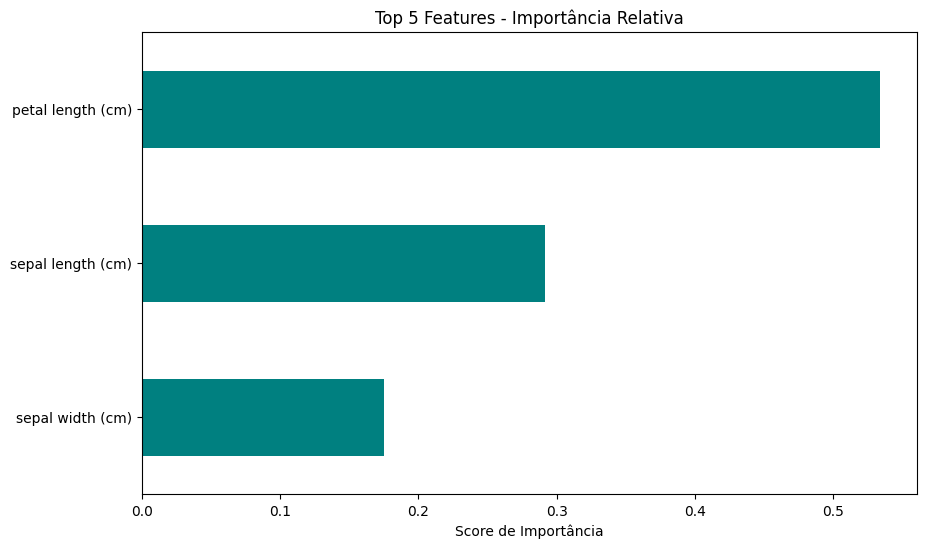

petal length (cm)    0.533493
sepal length (cm)    0.291427
sepal width (cm)     0.175080
dtype: float64

In [ ]:
# Carregar dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Exemplo de uso:
X_top, resumo, ranking = mlpo.feature_selector(X_train, y_train, k=5)
ranking

In [47]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_top, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
X_test_top = X_test[X_top.columns]

y_pred = model.predict(X_test_top)

In [51]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average=None))
print("Recall (macro):", recall_score(y_test, y_pred, average=None))
print("F1-score (macro):", f1_score(y_test, y_pred, average=None))

Accuracy: 0.9666666666666667
Precision (macro): [1.         1.         0.91666667]
Recall (macro): [1.         0.88888889 1.        ]
F1-score (macro): [1.         0.94117647 0.95652174]


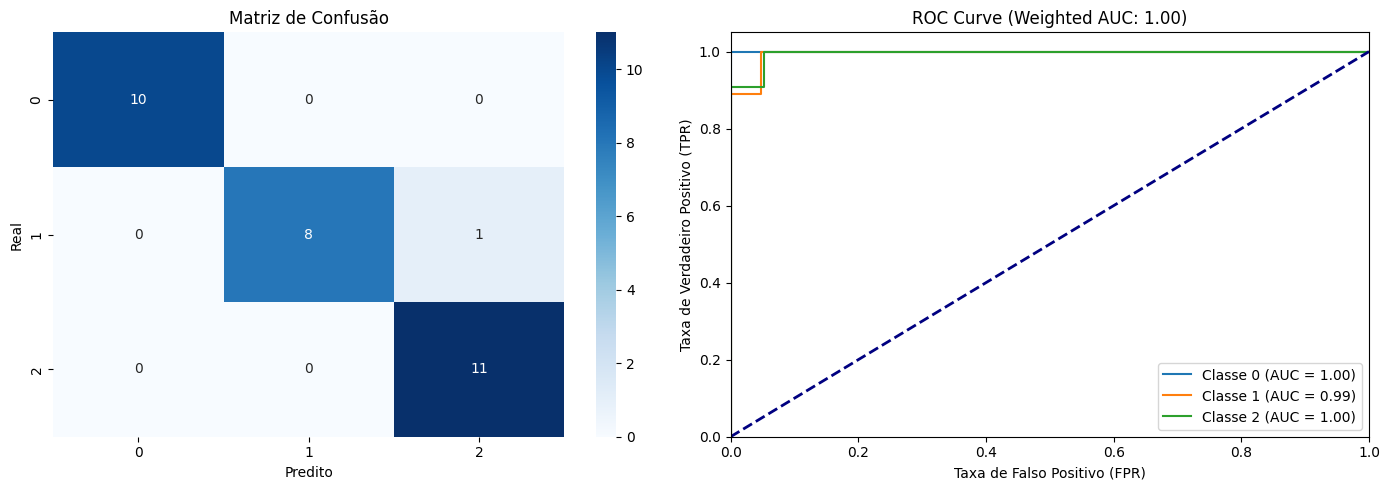

{'Accuracy': 0.9666666666666667,
 'Precision': 0.9694444444444444,
 'Recall': 0.9666666666666667,
 'F1 Score': 0.9664109121909632,
 'Confusion Matrix': array([[10,  0,  0],
        [ 0,  8,  1],
        [ 0,  0, 11]]),
 'ROC AUC': 0.9966583124477862}

In [ ]:
y_proba = model.predict_proba(X_test_top)

summary = mlpo.summarize_model_performance(
    y_test,
    y_pred,
    y_proba,
    multi_class=True,
    class_names=y_train.unique()
)

summary